# Four-model predictive mixture and polling mean shifts

We retain the final Gaussian, its matched Student-t, and the older Gaussian/Student-t pair. Each gets a **fixed25% probability** as a whole joint state forecast. We do not average state draws: that would artificially shrink uncertainty. Model disagreement adds uncertainty through the law of total covariance.

Then translate the mixture toward corrected polling at5/10/20/30/40/50%. The translation changes means but preserves the mixture's full centered distribution/covariance. The20% example below is fixed for display, not selected as optimal. No helper uncertainty is added. See [equations and validation](../docs/ENSEMBLE.md).

In [2]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT=next(p for p in [Path.cwd(),Path.cwd().parent] if (p/'election_lab.py').exists())
sys.path.insert(0,str(ROOT))
import election_lab as lab
import model_portfolio as portfolio
pd.set_option('display.max_rows',40)
RUN=lab.run_logged(portfolio.run)  # Content-verified cache; no downloads.
p=pd.read_parquet(RUN/'predictions.parquet')
s=pd.read_parquet(RUN/'seats.parquet')
summary=pd.read_parquet(RUN/'summary.parquet')
cycles=pd.read_parquet(RUN/'cycle_scores.parquet')
print('Immutable comparison:',RUN.relative_to(ROOT))

MODELS=['Bayesian','Matched Student-t (df5)','Older Gaussian','Student-t research helper','Non-Bayesian corrected','Four-model mixture','Mixture + polling 20%']
display(pd.Series(portfolio.configuration()['component_weights'],name='Mixture weight'))

Run log: cache/logs/run_20260921T044632.372975Z.txt
Immutable comparison: cache/runs/portfolio/20260921T044632.628767Z


Bayesian                     0.25
Matched Student-t (df5)      0.25
Older Gaussian               0.25
Student-t research helper    0.25
Name: Mixture weight, dtype: float64

## Paired historical results

Same2012–2024 folds; recent2016–2024 shown first. Each fit/tuning step uses prior cycles. These years were also used to explore architectures, so treat improvements as exploratory. No unseen election outcome optimized the mixture or shift weights.

MAE and interval widths are D−R percentage points. Brier/WIS: lower is better. `correct/n` is winner accuracy, not chamber accuracy. Nominal70% coverage should be near70%, not necessarily maximized. Probability metrics omit unavailable early non-Bayesian calibrations; `probability_n` exposes the denominator.

In [3]:
display(summary[summary.first_cycle.eq(2016)&summary.model.isin(MODELS)][['scenario','model','correct','n','absolute_error_pp','brier','coverage70','width70_pp','wis_pp','probability_n']].round(3))
display(cycles[cycles.model.isin(MODELS)][['scenario','cycle','model','n','correct','absolute_error_pp','brier']].round(3))

,scenario,model,correct,n,absolute_error_pp,brier,coverage70,width70_pp,wis_pp,probability_n
24,matched_live,Bayesian,128,140,6.307,0.055,78.571,19.876,3.822,140
25,matched_live,Four-model mixture,129,140,6.512,0.056,75.000,18.871,3.879,140
26,matched_live,Matched Student-t (df5),129,140,6.344,0.055,66.429,16.929,3.783,140
28,matched_live,Mixture + polling 20%,129,140,6.512,0.057,75.714,18.871,3.885,140
33,matched_live,Non-Bayesian corrected,127,140,7.472,0.078,90.090,28.406,4.770,111
34,matched_live,Older Gaussian,129,140,6.808,0.059,79.286,20.897,4.053,140
35,matched_live,Student-t research helper,129,140,6.801,0.058,66.429,17.751,3.999,140
36,oct31,Bayesian,132,140,5.206,0.050,73.571,15.800,3.054,140
37,oct31,Four-model mixture,132,140,5.275,0.050,67.143,14.419,3.055,140
38,oct31,Matched Student-t (df5),132,140,5.224,0.049,62.143,13.287,3.049,140


,scenario,cycle,model,n,correct,absolute_error_pp,brier
0,matched_live,2012,Bayesian,31,29.0,7.486,0.062
1,matched_live,2012,Four-model mixture,31,29.0,7.508,0.057
2,matched_live,2012,Matched Student-t (df5),31,28.0,7.605,0.060
4,matched_live,2012,Mixture + polling 20%,31,28.0,7.522,0.058
9,matched_live,2012,Non-Bayesian corrected,31,28.0,7.707,NaN
...,...,...,...,...,...,...,...
158,oct31,2024,Matched Student-t (df5),28,27.0,4.345,0.039
160,oct31,2024,Mixture + polling 20%,28,27.0,3.823,0.036
165,oct31,2024,Non-Bayesian corrected,28,26.0,3.103,0.038
166,oct31,2024,Older Gaussian,28,27.0,4.472,0.040


## Weight sensitivity

Fixed sensitivity grid, not a new optimized forecast. September and October are kept separate.

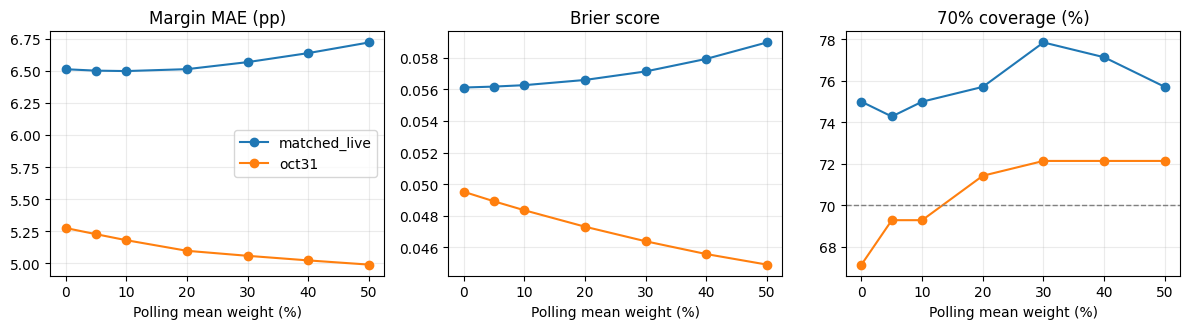

,scenario,poll_weight,correct,n,absolute_error_pp,brier,coverage70
25,matched_live,0.00,129,140,6.512,0.056,75.000
31,matched_live,0.05,129,140,6.501,0.056,74.286
27,matched_live,0.10,129,140,6.498,0.056,75.000
28,matched_live,0.20,129,140,6.512,0.057,75.714
29,matched_live,0.30,129,140,6.567,0.057,77.857
30,matched_live,0.40,129,140,6.638,0.058,77.143
32,matched_live,0.50,128,140,6.721,0.059,75.714
37,oct31,0.00,132,140,5.275,0.050,67.143
43,oct31,0.05,132,140,5.227,0.049,69.286
39,oct31,0.10,133,140,5.180,0.048,69.286


In [4]:
grid=summary[summary.first_cycle.eq(2016)&(summary.model.eq('Four-model mixture')|summary.model.str.startswith('Mixture + polling'))].copy()
grid['poll_weight']=grid.model.str.extract(r'(\d+)%').astype(float).fillna(0)/100
fig,axes=plt.subplots(1,3,figsize=(12,3.4))
for sc,g in grid.groupby('scenario'):
    g=g.sort_values('poll_weight')
    for ax,col,title in zip(axes,['absolute_error_pp','brier','coverage70'],['Margin MAE (pp)','Brier score','70% coverage (%)']):
        ax.plot(100*g.poll_weight,g[col],marker='o',label=sc);ax.set(xlabel='Polling mean weight (%)',title=title);ax.grid(alpha=.25)
axes[2].axhline(70,color='grey',ls='--',lw=1);axes[0].legend();fig.tight_layout();plt.show()
display(grid[['scenario','poll_weight','correct','n','absolute_error_pp','brier','coverage70']].sort_values(['scenario','poll_weight']).round(3))


## Live results

The reference stays first. Point totals, expected totals and control probability answer different questions; a heavier tail need not move them in the same direction. All current rows use the same saved data snapshot.

In [5]:
current=s[s.evidence.eq('live') & s.model.isin(MODELS)].copy()
current['D control %']=100*current.p_D_control
display(current[['model','point_D','point_R','expected_D','D control %','D_lo70','D_hi70']].round(3))
live=p[p.evidence.eq('live') & p.model.isin(MODELS)].copy()
print('D−R margin, percentage points')
display(live.pivot(index=['geography','special'],columns='model',values='margin_pp').reindex(columns=MODELS).round(2))
print('D win probability, percent')
display((100*live.pivot(index=['geography','special'],columns='model',values='p_dem')).reindex(columns=MODELS).round(1))


,model,point_D,point_R,expected_D,D control %,D_lo70,D_hi70
180,Bayesian,51,49,50.320,45.520,49.0,52.0
181,Non-Bayesian corrected,48,52,48.373,16.354,46.0,51.0
182,Older Gaussian,50,50,51.090,61.997,49.0,53.0
183,Student-t research helper,50,50,51.115,63.006,49.0,53.0
184,Matched Student-t (df5),51,49,50.476,50.028,49.0,52.0
185,Four-model mixture,50,50,50.748,55.138,49.0,53.0
188,Mixture + polling 20%,50,50,50.419,47.381,49.0,52.0


D−R margin, percentage points


,model,Bayesian,Matched Student-t (df5),Older Gaussian,Student-t research helper,Non-Bayesian corrected,Four-model mixture,Mixture + polling 20%
geography,special,,,,,,,
AK,False,-3.10,-2.87,-0.77,-0.86,-2.17,-1.90,-1.95
AL,False,-22.02,-21.94,-18.24,-18.62,-21.69,-20.21,-20.50
AR,False,-20.80,-19.23,-12.03,-11.70,-23.32,-15.94,-17.42
CO,False,17.44,17.62,14.13,14.40,5.95,15.90,13.91
DE,False,24.95,25.15,25.61,25.88,15.52,25.40,23.42
FL,True,-5.48,-5.32,-4.16,-4.14,-9.12,-4.78,-5.65
GA,False,5.22,5.31,5.94,5.90,3.39,5.59,5.15
IA,False,-3.27,-3.08,-2.80,-2.80,-5.46,-2.99,-3.48
ID,False,-25.97,-25.75,-27.04,-26.77,-29.76,-26.38,-27.06


D win probability, percent


,model,Bayesian,Matched Student-t (df5),Older Gaussian,Student-t research helper,Non-Bayesian corrected,Four-model mixture,Mixture + polling 20%
geography,special,,,,,,,
AK,False,30.0,27.5,45.9,44.3,43.1,37.0,36.7
AL,False,0.0,0.1,3.3,1.9,4.2,1.3,1.2
AR,False,0.2,0.8,14.4,9.5,3.1,6.3,4.8
CO,False,92.7,94.3,85.5,88.8,68.2,90.3,87.5
DE,False,99.9,99.6,99.3,98.9,89.2,99.4,99.2
FL,True,20.3,15.1,31.8,26.7,23.3,23.7,20.0
GA,False,80.8,86.4,78.3,83.6,60.7,82.1,80.1
IA,False,29.2,25.8,34.0,29.6,33.2,29.4,26.5
ID,False,0.0,0.3,0.1,0.5,0.9,0.2,0.2


## Full cycle chamber comparison and checks

Historical totals include continuing seats and documented completion of unmodeled contests. Final totals are100 seats, not gains. Mixture probabilities are weighted joint Monte Carlo estimates; component state probabilities may use lower-noise analytical/Rao–Blackwell estimates. Small numerical differences are expected.

In [6]:
display(s[s.evidence.eq('frozen')&s.cycle.le(2024)&s.model.isin(MODELS)][['scenario','cycle','model','point_D','actual_D','expected_D','p_D_control','D_lo70','D_hi70']].round(3))
checks=pd.read_parquet(RUN/'checks.parquet')
assert checks.covariance_preserved.all()
assert p[p.cycle.eq(2026)].actual.isna().all()
lab.verify_run(RUN)
print(len(checks),'mean-shift cases passed covariance/width invariance checks; manifests verified.')


,scenario,cycle,model,point_D,actual_D,expected_D,p_D_control,D_lo70,D_hi70
0,matched_live,2012,Non-Bayesian corrected,51,55.0,NaN,NaN,NaN,NaN
1,matched_live,2012,Bayesian,52,55.0,50.766,0.563,49.0,53.0
2,matched_live,2012,Older Gaussian,51,55.0,50.746,0.556,49.0,53.0
3,matched_live,2012,Student-t research helper,51,55.0,51.060,0.632,49.0,53.0
4,matched_live,2012,Matched Student-t (df5),51,55.0,50.959,0.613,49.0,53.0
...,...,...,...,...,...,...,...,...,...
170,oct31,2024,Older Gaussian,48,47.0,48.238,0.042,47.0,50.0
171,oct31,2024,Student-t research helper,48,47.0,48.203,0.020,47.0,49.0
172,oct31,2024,Matched Student-t (df5),48,47.0,47.982,0.012,47.0,49.0
173,oct31,2024,Four-model mixture,48,47.0,48.096,0.024,47.0,49.0


105 mean-shift cases passed covariance/width invariance checks; manifests verified.


In [7]:
# Stable, Git-friendly published report (replaced on each rerun).
from IPython.display import FileLink
import os
PUBLISHED_REPORT = ROOT/'outputs/reports/experiments/portfolio.md'
print('Published report:', PUBLISHED_REPORT.relative_to(ROOT))
display(FileLink(os.path.relpath(PUBLISHED_REPORT, Path.cwd())))


Published report: outputs/reports/experiments/portfolio.md


/Users/amir/projects/small_models/us_election_2026/outputs/reports/experiments/portfolio.md